# <font size="8">AI Project: To Develop a Machine Learning Model that Predicts the Disease Stage of an MRI Image.</font>


# <font size="8">Environment Setup</font>

- Library Installations

- Library Imports

- Configuration and Reproducibility

- File Path Establishment




# Library Installations

In [ ]:
# Library Installations
# Uncomment these if you are running outside of Google Colab or if these packages are already installed

#! pip install matplotlib
#! pip install numpy
#! pip install tensorflow
#! pip install scikit-learn
#! pip install pillow
#! pip install opencv-python
#! pip install matplotlib
#! pip install numpy pandas
#! pip install matplotlib
#! pip install seaborn
#! pip install tensorflow
#! pip install scikit-learn
#! pip install opencv-python
#! pip install tqdm

# Library Imports

In [ ]:
# Library Imports

# System & Helper Libraries
import os
import gc
import zipfile
import random
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from PIL import Image
from tqdm import tqdm
from google.colab import drive


# Metrics (Scikit-Learn)
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, roc_curve, auc
)
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize


# Deep Learning Components (TensorFlow/Keras)
from tensorflow.keras import layers, model
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input, Rescaling
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Configuration and Reproducibility

In [2]:
# Configuration & Reproducibility

# Suppresses non-critical warning messages to keep the console output clean during execution
warnings.filterwarnings('ignore')

# Defines a universal constant for random states
SEED = 42

# Fixes Python's internal hash randomization to ensure consistent dictionary and set ordering
os.environ['PYTHONHASHSEED'] = str(SEED)

# Set the seed for Python's built-in random module (affects standard library random operations)
random.seed(SEED)

# Setting the seed for NumPy's random number generator (ensures consistent array shuffling/math operations)
np.random.seed(SEED)

# Setting the seed for TensorFlow (reproducible weight initialisation, dropout, and dataset shuffling)
tf.random.set_seed(SEED)

# Standardises the pixel size for the images
IMG_SIZE = (224, 224)

# Standardised batch size for the data.
# It defines the number of images propagated through the network in a single forward/backward pass
BATCH_SIZE = 32

# File Path Establishment

In [ ]:
# Setting a file path on google colab

# Change your file path to your own directory which has the MRI images if not running on Google Colab to reproduce the code. 
# The code is designed to run on Google Colab, so it uses the google drive mounting system to access the dataset stored in the user's google drive.
# The reasoning behing this is so that the training and testing of the model can be done on the GPU provided by Google Colab, which is much faster than training on a local machine.

# Mounting google drive to the '/content/drive' directory in the colab runtime
# This prompts for an authorisation, allowing access to files stored in your google drive
drive.mount('/content/drive')

# Defining the file path to the dataset in the Google Drive
ZIP_PATH = '/content/drive/MyDrive/AD_Dataset.zip'

# Defining the local directory path within Colab, where the files will be extracted
EXTRACT_PATH = '/content/dataset'



# Checks if the extraction directory already exists to prevent redundant unzipping
if not os.path.exists(EXTRACT_PATH):
    print("Extracting dataset")

    # Open the zip file in read mode ('r') using a context manager (ensures safe file closing)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:

        # Extract all contents of the zip archive into the specified local directory
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction successful.")
else:
    print("Dataset already extracted.")



# Defining the final path where the actual disease state folders are located inside the extracted directory
DATA_PATH = os.path.join(EXTRACT_PATH, 'AD copy')



# Verify that the expected data directory structure actually exists after extraction
if os.path.exists(DATA_PATH):

    # Reading the contenst of the data directory and sorts them alphabetically to identify the target classes
    classes = sorted(os.listdir(DATA_PATH))

    # Print the verified path to confirm the location is correct
    print(f"Data Path Verified: {DATA_PATH}")

    # Print the detected class names
    print(f"Detected Classes: {classes}")
else:
    # Output an error message if the folder structure inside the zip wasn't what was expected
    print(f"Error: {DATA_PATH} not found. Check zip structure.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Data Path Verified: /content/dataset/AD copy
Detected Classes: ['.DS_Store', '.venv', 'MildImpairment', 'ModerateImpairment', 'NoImpairment']


# <font size="8">Data Visualisation</font>
- Visualising Raw MRI Images
- Visualising Raw Class Distribution


# Visualising Raw MRI Images

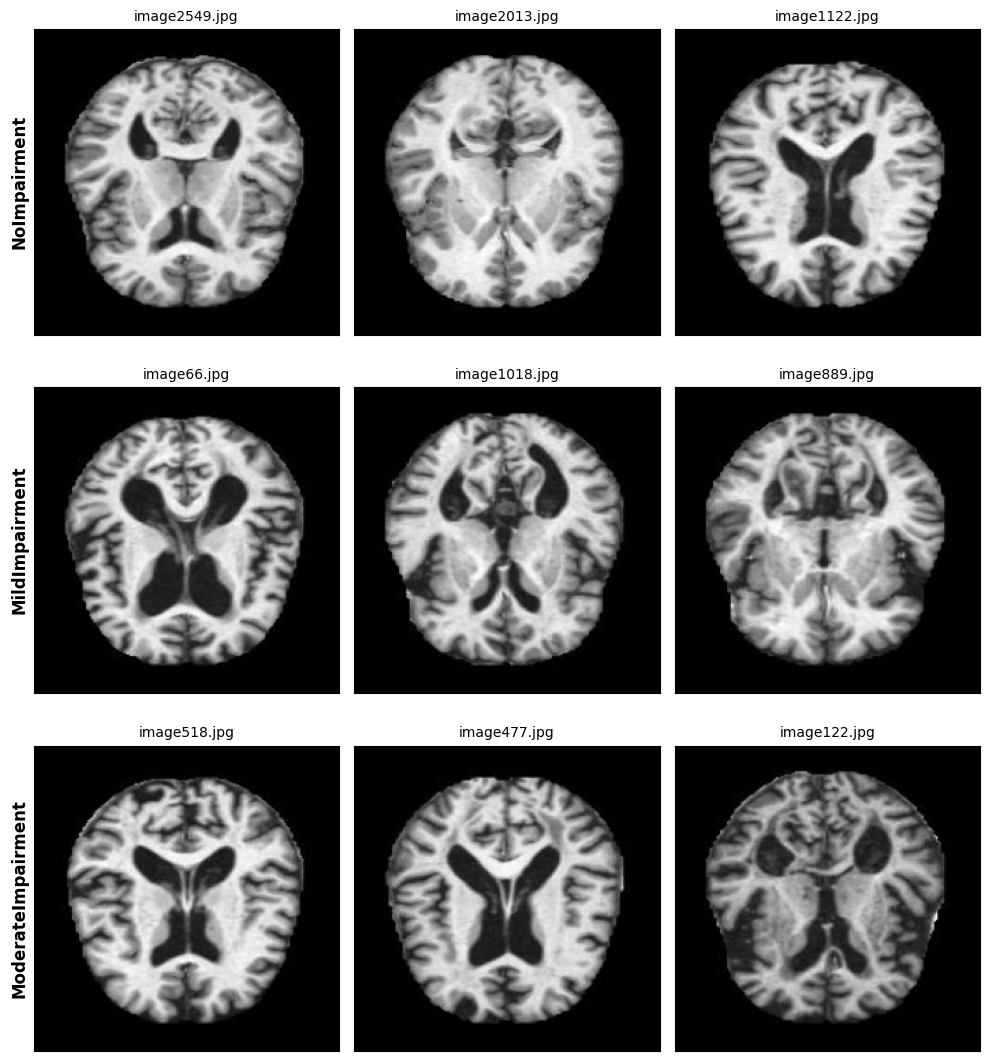

In [4]:
# Visualising the MRI images directly from the raw folders

# Defines the disease states in the "correct" order to plot the figure
disease_states = ['NoImpairment', 'MildImpairment', 'ModerateImpairment']
ncols = 3  # Number of images per row (3)

# Creates the figure with 3 rows (one for each disease state)
fig, axs = plt.subplots(nrows=len(disease_states), ncols=ncols, figsize=(10, 11))

# Loops through each disease state (Row)
for row, class_names in enumerate(disease_states):

    # Points you directly to the raw folder for this disease state
    folder_path = os.path.join(DATA_PATH, class_names)

    # We loop through extensions to grab images and ignore junk like .DS_Store
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    # Randomly selects 3 images
    n_samples = min(len(image_paths), ncols)
    sample_paths = random.sample(image_paths, n_samples)

    # Loops through the selected images
    for col, filepath in enumerate(sample_paths):
        ax = axs[row, col]

        # Load grayscale and resize using the constant "IMG_SIZE" (224x224)
        img = cv.imread(filepath, cv.IMREAD_GRAYSCALE)
        img_resized = cv.resize(img, IMG_SIZE)

        # Plot the figure
        ax.imshow(img_resized, cmap='gray')
        ax.set_title(os.path.basename(filepath), fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # Row labels
    axs[row, 0].set_ylabel(class_names, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualising Raw Class Distribution

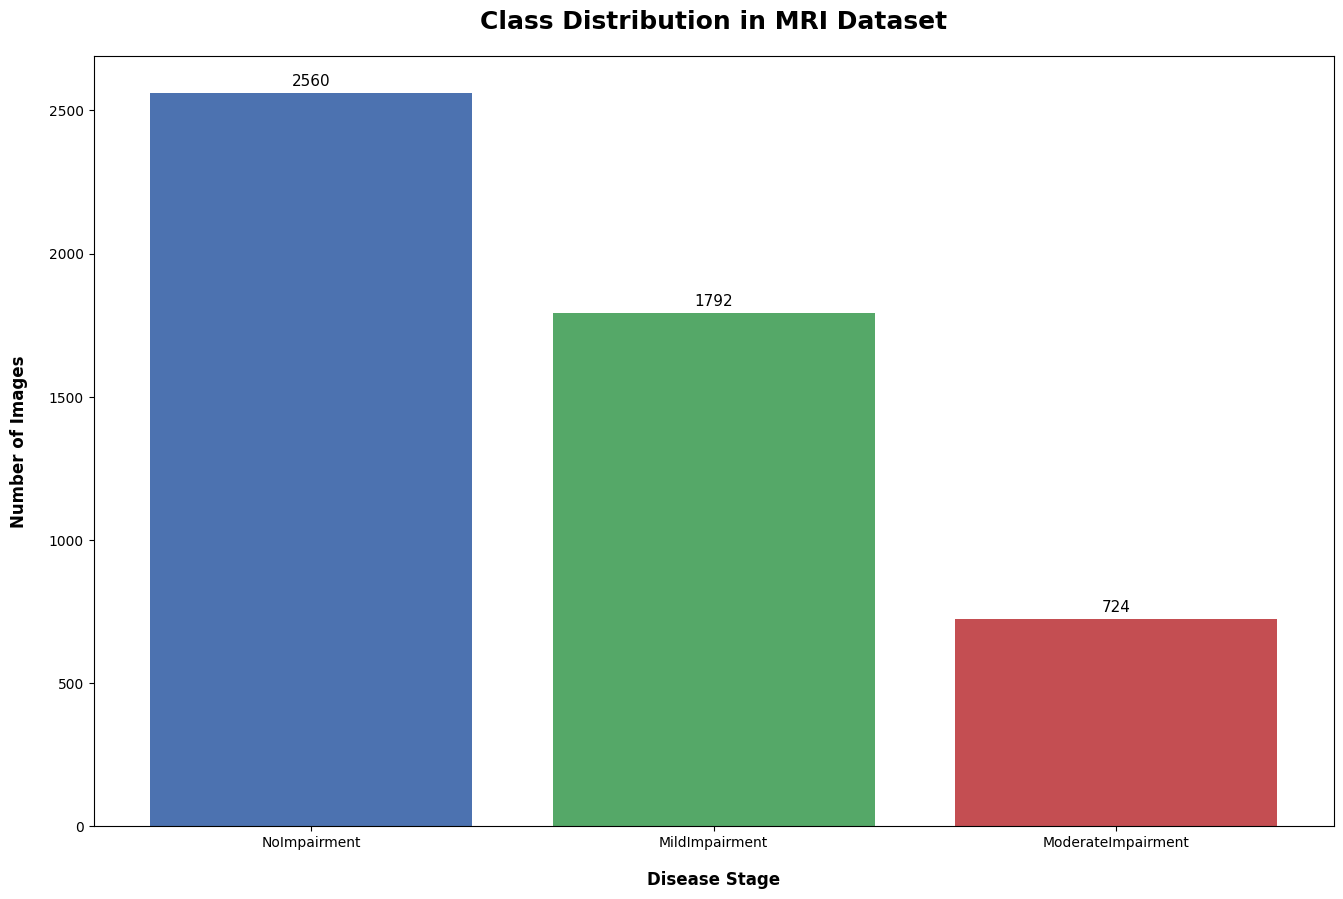


Dataset Balance:
 - NoImpairment: 50.4%
 - MildImpairment: 35.3%
 - ModerateImpairment: 14.3%


In [5]:
# Visualising Class Distribution from the raw folders

disease_states = ['NoImpairment', 'MildImpairment', 'ModerateImpairment']
colors = ['#4c72b0', '#55a868', '#c44e52']

# Count images directly from the folders using a quick list comprehension
heights = [len(glob.glob(f"{DATA_PATH}/{cls}/*.*")) for cls in disease_states]
total_imgs = sum(heights)

# Now we can create the Bar Chart
plt.figure(figsize=(16, 10))
bars = plt.bar(disease_states, heights, color=colors)

plt.ylabel('Number of Images', fontsize=12, labelpad=15, fontweight='bold')
plt.xlabel('Disease Stage', fontsize=12, labelpad=15, fontweight='bold')
plt.title('Class Distribution in MRI Dataset', fontsize=18, pad=20, fontweight='bold')

# Automatically add text labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(heights)*0.01),
             int(yval), ha='center', fontsize=11)

plt.show()


# Print percentages of class distribution
print("\nDataset Balance:")
for cls, count in zip(disease_states, heights):
    print(f" - {cls}: {count/total_imgs:.1%}")

# <font size="8">Dataset Preprocessing</font>
- Data Loading and Stratified Splitting
- Image Normalisation, Label Encoding and CLAHE Implementation
- CLAHE visualisation
- Calculating Weights


# Data Loading and Stratified Splitting

In [6]:
# Dataset Loading and Splitting
# I'm manually splitting each class to ensure 'Stratification' (Equal ratios in all sets)
# This is better than a basic random split

# Defining the classes (disease states)
# Maps folder names to integer labels
class_map = {
    "NoImpairment": 0,
    "MildImpairment": 1,
    "ModerateImpairment": 2
}

# Lists to store the splits before combining
train_list = []
val_list = []
test_list = []

print("\n-----------------------------------------")
print("Processing Images by Disease State")
print("-----------------------------------------")


# Iterating through each class and its corresponding integer label to process them independently
for class_name, label in class_map.items():

    # Constructing the path to the specific class folder
    folder_path = os.path.join(DATA_PATH, class_name)

    # Grabs all files in the folder instantly using glob
    image_paths = glob.glob(f"{folder_path}/*.*")

    # Safety Check: Checks to see if we found the images
    if len(image_paths) == 0:
        print(f"No images found in {folder_path}.")
        continue

    # Creating a temporary pandas DataFrame to organise the data dor the current class
    df = pd.DataFrame({
        "filepath": image_paths,    # Stores the absolute path to the image
        "label": str(label),        # Converts the integer label to a string for Keras compatibility (0, 1, 2)
        "class_name": class_name
    })

    # Randomly shuffles the rows of the Dataframe using the global seed to remove any inherent file-ording bias
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    # Calculating the total number of images available for this specific class
    total_count = len(df)

    # Calculating the integer size of the test set by taking 20% of the total class count
    test_count = int(0.2 * total_count)

    # Isolates the first 20% of the shuffled Dataframe to serve as the test set
    df_test = df.iloc[:test_count]

    # Isolates the remaining 80% of the data to be used for the training and validation phases
    train_val_df = df.iloc[test_count:]

    # Calculating the training set size by taking 80% of the remaining train/val pool
    train_count = int(0.8 * len(train_val_df))

    # Slicing the train/val pool to assign the first 80% to training and the remaining 20% to validation
    df_train = train_val_df.iloc[:train_count]
    df_val = train_val_df.iloc[train_count:]

    # Append the newly created stratified subsets for this class to their respective lists
    train_list.append(df_train)
    val_list.append(df_val)
    test_list.append(df_test)

    print(f"[{class_name}] Found: {total_count} -> Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# Combining and shuffling the final datasets
train_df = pd.concat(train_list).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_list).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_list).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Converting labels to string for Keras flow_from_dataframe requirements
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

print("\n-----------------------------------------")
print("Final Dataset Split")
print("-----------------------------------------")
print(f"Total Training Images:   {len(train_df)}")
print(f"Total Validation Images: {len(val_df)}")
print(f"Total Testing Images:    {len(test_df)}")


-----------------------------------------
Processing Images by Disease State
-----------------------------------------
[NoImpairment] Found: 2560 -> Train: 1638 | Val: 410 | Test: 512
[MildImpairment] Found: 1792 -> Train: 1147 | Val: 287 | Test: 358
[ModerateImpairment] Found: 724 -> Train: 464 | Val: 116 | Test: 144

-----------------------------------------
Final Dataset Split
-----------------------------------------
Total Training Images:   3249
Total Validation Images: 813
Total Testing Images:    1014


# Image Normalisation and Label Encoding and CLAHE Implementation
- Image processing:
- Label Encoding
- CLAHE Implementation

In [7]:
def load_image(filepath):
    """
    Loads raw MRI scans, standardises spatial dimensions to 224x224,
    and normalizes pixel intensities to a 0.0-1.0 scale.
    """
    img = cv.imread(filepath)

    # Safety Check: Return a blank array of the correct shape if the file is unreadable
    if img is None:
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3))

    # Color Correction: Convert the default OpenCV BGR color space to standard RGB
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # CLAHE Contrast Enhancement
    # Converting to LAB space to isolate lightness, apply CLAHE, then convert back to RGB
    lab = cv.cvtColor(img, cv.COLOR_RGB2LAB)
    l, a, b = cv.split(lab)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv.merge((cl,a,b))
    img = cv.cvtColor(limg, cv.COLOR_LAB2RGB)

    # Spatial Standardization: Resize all images to the required uniform dimensions (224, 224)
    img = cv.resize(img, IMG_SIZE)

    # Normalisation: Scale pixel values from 0-255 down to 0.0-1.0 to stabilise the training of the model
    # float32 saves 50% RAM
    return (img / 255.0).astype(np.float32)


def process_dataframe(df, dataset_name):
    """
    Iterates through dataset splits, processes images, and applies one-hot
    encoding to the categorical labels for model ingestion.
    """
    print("-----------------------------------------")
    print(f"Processing {dataset_name} ({len(df)})")
    print("-----------------------------------------")

    X_list, y_raw_list = [], []

    # Iterate through the dataframe rows using tqdm for a visual progress bar
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Process the image and append it features list
        X_list.append(load_image(row['filepath']))

        # Extracting the integer label (0, 1, or 2) and appending it to the labels list
        y_raw_list.append(int(row['label']))

    # Converting the populated Python lists into NumPy arrays for tensor operations
    X = np.array(X_list)
    y_raw = np.array(y_raw_list)

    # One-Hot Encoding: Converting the 1D integer labels into a 2D binary matrix
    # (e.g., class 1 becomes [0, 1, 0]) using Keras' built-in utility
    y_encoded = to_categorical(y_raw, num_classes=3)

    return X, y_encoded, y_raw


# Process the training set, keeping the raw labels for class weight calculations later
xtrain, ytrain, y_train_lab = process_dataframe(train_df, "Train Set")

# Process validation and test sets (discarding raw labels using '_' as they aren't needed here)
xval, yval, _ = process_dataframe(val_df, "Validation Set")
xtest, ytest, _ = process_dataframe(test_df, "Test Set")

# Final Verification of tensor dimensions to ensure the pipeline worked correctly
print("\nFinal Dimensions")
print("-----------------------------------------")
print(f"xtrain: {xtrain.shape} | ytrain: {ytrain.shape}")
print(f"xval:   {xval.shape}   | yval:   {yval.shape}")
print(f"xtest:  {xtest.shape}  | ytest:  {ytest.shape}")

-----------------------------------------
Processing Train Set (3249)
-----------------------------------------


100%|██████████| 3249/3249 [00:07<00:00, 440.39it/s]


-----------------------------------------
Processing Validation Set (813)
-----------------------------------------


100%|██████████| 813/813 [00:01<00:00, 474.28it/s]


-----------------------------------------
Processing Test Set (1014)
-----------------------------------------


100%|██████████| 1014/1014 [00:02<00:00, 484.57it/s]



Final Dimensions
-----------------------------------------
xtrain: (3249, 224, 224, 3) | ytrain: (3249, 3)
xval:   (813, 224, 224, 3)   | yval:   (813, 3)
xtest:  (1014, 224, 224, 3)  | ytest:  (1014, 3)


# CLAHE Visualisation

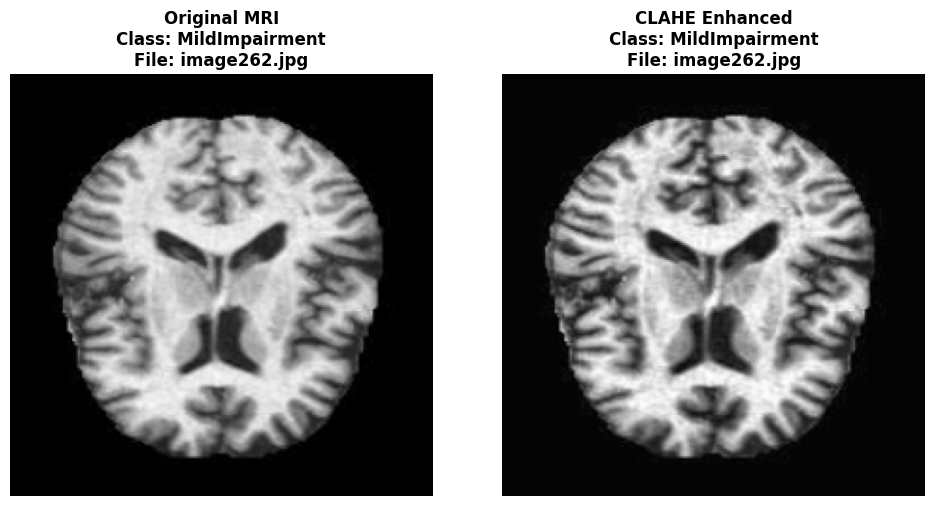

In [8]:
# Picking a random clinical class folder and grabbing a single random raw image file path (from the training set)
sample_row = train_df.sample(1, random_state=SEED).iloc[0]
sample_path = sample_row['filepath']
sample_class = sample_row['class_name']
image_filename = os.path.basename(sample_path)


# Loading and resizing the raw image normally
img_before = cv.imread(sample_path)
img_before = cv.cvtColor(img_before, cv.COLOR_BGR2RGB)
img_before = cv.resize(img_before, IMG_SIZE)


# Passing the path through the unified preprocessing function
# This automatically applies CLAHE, resizing and float32 normalisation
img_after = load_image(sample_path)


# Plotting the comparison of the images side-by-side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


# Plotting the Original MRI image
axs[0].imshow(img_before)
axs[0].set_title(f"Original MRI\nClass: {sample_class}\nFile: {image_filename}", fontweight='bold', fontsize=12)
axs[0].axis('off')


# Plotting Enhanced MRI image (with CLAHE, clip limit of 2.0)
axs[1].imshow(img_after)
axs[1].set_title(f"CLAHE Enhanced\nClass: {sample_class}\nFile: {image_filename}", fontweight='bold', fontsize=12)
axs[1].axis('off')


plt.tight_layout()
plt.show()

# Calculating Weights

In [9]:
# Calculating the weights automatically based on your specific 'y_train_lab' data
# This fixes the imbalance issue mathematically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_lab),
    y=y_train_lab
)

# Creating the "dictionary" variable that the training cell is looking for
class_weights_dict = dict(enumerate(class_weights))

print("Class Weightings")
print(class_weights_dict)

Class Weightings
{0: np.float64(0.6611721611721612), 1: np.float64(0.944202266782912), 2: np.float64(2.334051724137931)}


# <font size="8">Model 1: Custom CNN Without ResNet</font>
- Defining the Model Architecture
- Visualising Data Augmentation
- Building the Main Model
- Compiling the Baseline Model
- Training Model 1
- Visualisations and Plots for Model 1

# Defining the Model Architecture

In [10]:
# Defining the Model Architecture

# Defining Data Augmentation Block
# It only runs during training (automatically turned off during testing).
# It applies random, slight spatial and visual transformations to artificially expand the dataset
# This prevents the model from memorizing specific training images (overfitting).
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                   # Simulates left/right brain hemisphere symmetry
    tf.keras.layers.RandomRotation(0.05, fill_mode="constant"), # Simulates slight tilt in patient head positioning (5%)
    tf.keras.layers.RandomZoom(0.05, fill_mode="constant"),     # Simulates variations in brain size/scanner scaling
    tf.keras.layers.RandomContrast(0.05),                       # Simulates slight differences in MRI machine calibrations
    tf.keras.layers.RandomTranslation(0.05, 0.05)               # Simulates off-center patient positioning
], name="Augmentation_Block")




# Defining Convolutional Block
# Uses SeparableConv2D which performs spatial and depthwise convolutions separately.
# This significantly reduces the number of parameters and computational cost compared to standard Conv2D, while maintaining feature extraction capabilities.
def conv_block(filters):
    block = tf.keras.Sequential([

        # First separable convolution layer to extract spatial features
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),

        # Second separable convolution for deeper feature representation
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),

        # Normalizes the activations from the previous layer to stabilise and speed up training
        tf.keras.layers.BatchNormalization(),

        # Downsamples the spatial dimensions by taking the maximum value in a 2x2 window,
        # reducing computational load and isolating the most prominent features
        tf.keras.layers.MaxPool2D()
    ])
    return block




# Dense Classification Block
# Constructs a standardized Fully Connected (Dense) block for final classification.
# Incorporates strong regularization (Dropout) to prevent the network from relying too heavily on any single node.
def dense_block(units, dropout_rate):
    block = tf.keras.Sequential([
        tf.keras.layers.Dense(units, activation='relu'),

        # Normalize outputs to maintain a stable gradient flow into the next layers
        tf.keras.layers.BatchNormalization(),

        # Randomly disable a percentage (dropout_rate) of neurons during training
        # This is to force the network to learn robust, distributed representations
        tf.keras.layers.Dropout(dropout_rate)
    ])
    return block

# Visualising Data Augmentation

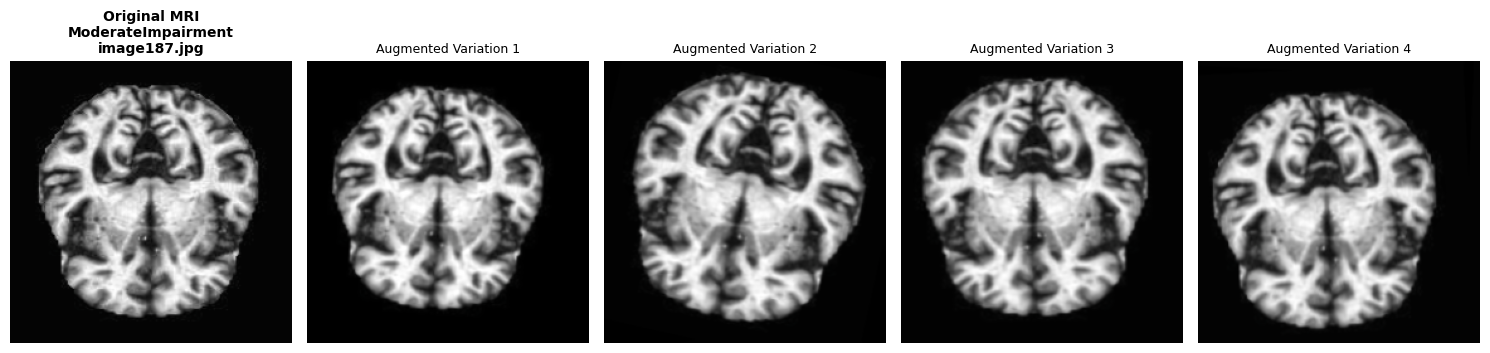

In [30]:
def plot_augmentation_samples(image_data, dataframe):
    # Selecting a random index
    idx = np.random.randint(0, len(image_data))
    sample_image = image_data[idx]

    # Extracting the class and filename from the existing dataframe
    sample_class = dataframe.iloc[idx]['class_name']
    sample_filename = os.path.basename(dataframe.iloc[idx]['filepath'])

    # Plotting
    plt.figure(figsize=(15, 5))

    # Show Original with metadata
    plt.subplot(1, 5, 1)
    plt.imshow(sample_image)
    plt.title(f"Original MRI\n{sample_class}\n{sample_filename}", fontweight='bold', fontsize=10)
    plt.axis('off')

    # Show 4 random variations using the Augmentation_Block
    for i in range(4):
        # training=True ensures the random transformations are active
        augmented_img = data_augmentation(tf.expand_dims(sample_image, 0), training=True)

        plt.subplot(1, 5, i+2)
        plt.imshow(augmented_img[0])                         # Remove batch dimension to plot
        plt.title(f"Augmented Variation {i+1}", fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the verification (passing in xtrain and our training dataframe)
plot_augmentation_samples(xtrain, train_df)

# Building the Main Model

In [11]:
# Building the Main Model

# Constructing the full Custom Convolutional Neural Network sequentially.
# Combining the augmentation pipeline, custom convolutional blocks, and optimized dense classification layers.



def build_model():
    model = tf.keras.Sequential([

        # Input Layer
        # Defines the exact spatial and color channel dimensions that the network should expect.
        tf.keras.Input(shape=(*IMG_SIZE, 3)),

        # Data Augmentation
        # Injects the pre-defined spatial and contrast variations directly into the pipeline.
        data_augmentation,

        # Initial Conv Layer (relu)
        # Standard Conv2D layers used at the very beginning to capture basic, low-level
        # features (like skull boundaries or major structural lines) before using the more complex separable convolutions.
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(),

        # Deep Convolutional Blocks
        # Progressively increasing the number of filters (128 -> 256 -> 512 -> 728)
        # Allows the network to learn increasingly complex, abstract representations of Alzheimer's.
        conv_block(128),
        conv_block(256),
        tf.keras.layers.Dropout(0.2),  # Drops 20% of connections to prevent overfitting early on

        conv_block(512),
        tf.keras.layers.Dropout(0.3),  # Increases dropout as the network gets deeper and more complex

        conv_block(728),
        tf.keras.layers.Dropout(0.3),

        # Spatial Reduction
        # Replaces the traditional Flatten() layer.
        # Drastically reduces total parameter count, making the model computationally lighter and highly resistant to overfitting.
        tf.keras.layers.GlobalAveragePooling2D(),

        # Dense Classification Blocks
        dense_block(512, 0.5),  # 50% dropout for strong regularization
        dense_block(256, 0.3),

        # Output Layer
        # Uses 3 units corresponding directly to the 3 disease states
        # The 'softmax' activation function converts the raw outputs into a clean, percentage-based probability distribution
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    return model

# Compiling the Baseline model

In [12]:
# Compiling the Baseline Model

# Definingg Evaluation Metrics
# I'm defining the specific metrics the model will track during training and validation.
METRICS = [
            # I'm using AUC because it handles imbalance better than accuracy
            tf.keras.metrics.AUC(name='auc'),

            # Standard categorical accuracy tracks the raw percentage of correct predictions.
            tf.keras.metrics.CategoricalAccuracy(name='accuracy')
]



# Building and Compiling Section of the Model
model = build_model()

model.compile(

    # Optimizer: Adam is an adaptive learning rate optimization algorithm.
    # Learning rate set to 0.001.
    # clipnorm=1.0 caps the maximum size of the gradients during backpropagation, preventing the "exploding gradient" problem and ensuring stable learning.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),

    # Loss Function: Categorical Crossentropy is the mathematical standard for multi-class classification problems, where labels are one-hot encoded (like our established [0,1,0] arrays).
    loss=tf.keras.losses.CategoricalCrossentropy(),

    # Attaching our custom metrics
    metrics=METRICS
)

# Prints highly detailed table showing every layer, its output shape, and the total number of trainable vs. non-trainable parameters.
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Augmentation_Block (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 56, 56, 128)    │        27,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 256)    │       103,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 14, 14, 512)    │       403,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 7, 7, 728)      │       918,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 728)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 728)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 512)            │       375,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 256)            │       132,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,998,955 (7.63 MB)

 Trainable params: 1,994,171 (7.61 MB)

 Non-trainable params: 4,784 (18.69 KB)

# Training Model 1

In [13]:
# Training the Model

# Defining Training Callbacks
callbacks_list = [
    # ModelCheckpoint: Continuously monitors the Validation AUC during training.
    # It only saves the model weights if the current epoch achieves a higher AUC than any previous epoch, ensuring we keep the absolute best version.
    ModelCheckpoint("best_alzheimer_model_clahe.keras", save_best_only=True, monitor='val_auc', mode='max'),

    # EarlyStopping: Prevents severe overfitting. If the Validation AUC does not improve
    # for 10 consecutive epochs (patience=10), it aborts the training process early and
    # automatically restores the weights from the best recorded epochs
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_auc', mode='max'),

    # Scheduler: If stuck, cuts learning rate in half
    # Updated min_lr to 0.0001 as you requested
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=0.00001, verbose=1, mode='max')
]

# class_weights_dict are used here to handle the class imbalance
# The history dictionary captures metrics for every single epoch, for later visualization.
history = model.fit(
    xtrain, ytrain,
    batch_size=BATCH_SIZE,           # Number of images processed at once before updating weights
    epochs=50,                       # Maximum number of full passes through the dataset
    validation_data=(xval, yval),    # Tests the model on unseen data at the end of each epoch
    callbacks=callbacks_list,
    class_weight=class_weights_dict, # Applies the weightings, to tackle class imbalance
    verbose=1,                       # Prints a live progress bar to the console
    shuffle=True                     # Shuffles the training data each epoch to prevent memorization of order
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 481ms/step - accuracy: 0.4050 - auc: 0.5702 - loss: 1.1509 - val_accuracy: 0.5043 - val_auc: 0.6430 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 463ms/step - accuracy: 0.4460 - auc: 0.6536 - loss: 1.0518 - val_accuracy: 0.5043 - val_auc: 0.6808 - val_loss: 1.0309 - learning_rate: 0.0010
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 458ms/step - accuracy: 0.4615 - auc: 0.6685 - loss: 1.0259 - val_accuracy: 0.3530 - val_auc: 0.6052 - val_loss: 1.0846 - learning_rate: 0.0010
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 457ms/step - accuracy: 0.4606 - auc: 0.6707 - loss: 1.0129 - val_accuracy: 0.3530 - val_auc: 0.4262 - val_loss: 1.3131 - learning_rate: 0.0010
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 458ms/step - accuracy: 0.4854 - auc: 0.7037 - loss: 0.9591 - val_accuracy: 0.5043 - val_auc: 0.7227 - val_loss: 1.0029 - learning_rate: 0.0010
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 453ms/step - accuracy

# Visualisations and Plots for Model 1

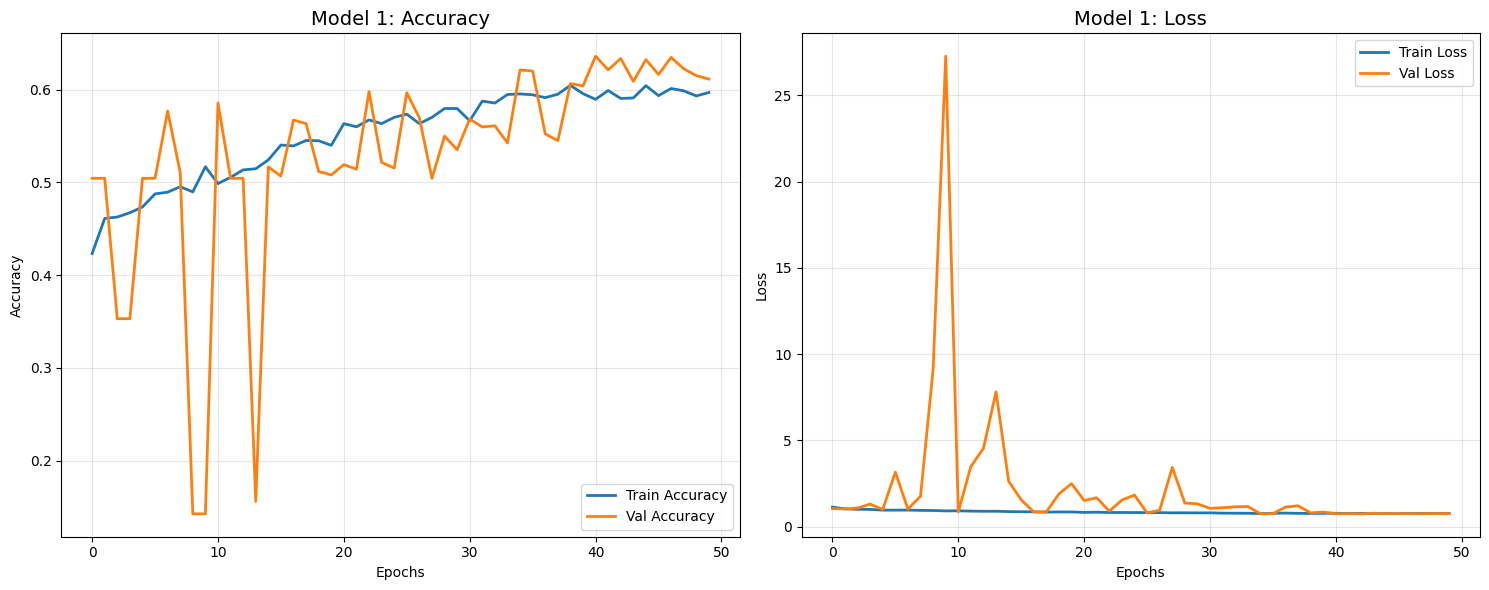

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step

Model 1: Classification Report
                    precision    recall  f1-score   support

      NoImpairment       0.76      0.68      0.71       512
    MildImpairment       0.48      0.51      0.49       358
ModerateImpairment       0.49      0.59      0.54       144

          accuracy                           0.61      1014
         macro avg       0.58      0.59      0.58      1014
      weighted avg       0.62      0.61      0.61      1014



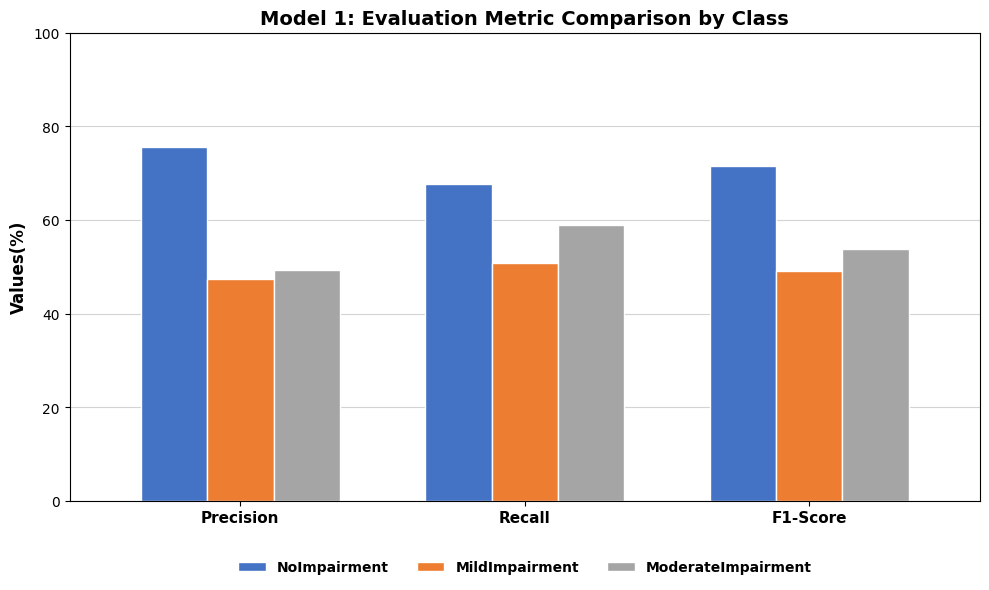

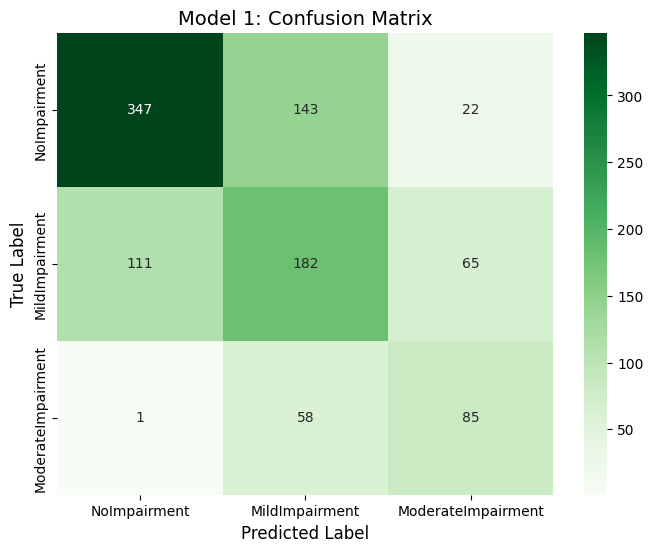

In [24]:
# Visualisations and Plots for Model 1

# Plotting training curves
# Using the 'history' variable from the training cell
hist = history.history
plt.figure(figsize=(15, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
plt.plot(hist['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Model 1: Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss (error) Plot
plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(hist['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
plt.title('Model 1: Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Generating predictions
# 'model' is used in the training cell
predictions = model.predict(xtest)

# Convert probabilities to class integers (0, 1, 2)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(ytest, axis=1)


# Classification report
class_names = ['NoImpairment', 'MildImpairment', 'ModerateImpairment']

print("\n" + "="*50)
print("Model 1: Classification Report")
print("="*50)
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Bar Chart of Classification Report
# Generating report as dictionary
report_dict = classification_report(y_true_classes, y_pred_classes, target_names=class_names, output_dict=True)

# Filtering out summary rows and isolate the metrics
df = pd.DataFrame(report_dict).T.drop(['accuracy', 'macro avg', 'weighted avg'])[['precision', 'recall', 'f1-score']]

# Transpose (flip) so Metrics are on the X-axis, and multiply by 100 for percentages
plot_df = df.T * 100

# Adding Unique colors
colors = ['#4472C4', '#ED7D31', '#A5A5A5']
ax = plot_df.plot(kind='bar', figsize=(10, 6), color=colors, width=0.7, edgecolor='white')

# Formatting
plt.title('Model 1: Evaluation Metric Comparison by Class', fontweight='bold', fontsize=14)
plt.ylabel('Values(%)', fontweight='bold', fontsize=12)
plt.xlabel('') # Left blank as the tick labels are self-explanatory

# Capitalize and bold X-axis labels
plt.xticks(ticks=[0, 1, 2], labels=['Precision', 'Recall', 'F1-Score'], rotation=0, fontweight='bold', fontsize=11)
plt.ylim(0, 100)

# Moving legend to the bottom center, spread horizontally (ncol=3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, prop={'weight':'bold'})

# Adding solid light-gray horizontal gridlines behind the bars
ax.set_axisbelow(True)
plt.grid(axis='y', color='lightgray', linestyle='-')

plt.tight_layout()
plt.show()


# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,               # Show the raw numbers inside the boxes
            fmt='d',                  # Format as integers (no decimals)
            cmap='Greens',            # Green color gradient
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Model 1: Confusion Matrix', fontsize=14)
plt.show()




# <font size="8">Model 2: ResNet50V2</font>
- Defining the Model Architecture
- Warmup phase
- Fine-tuning phase
- Visualisations and Plots for Model 2

# Defining the Model Architecture

In [18]:
# Defining Model Architecture

# Constructing a Transfer Learning pipeline using a pre-trained ResNet50V2 base,
# coupled with a custom classification head tailored for Alzheimer's diagnosis.
def build_resnet_model():
    # Base Model (Frozen)
    # include_top=False removes the original 1000-class ImageNet classifier.
    base_model = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    # Freezing the pre-trained weights so they are not destroyed during initial training
    base_model.trainable = False

    # Input Layer
    inputs = layers.Input(shape=(224, 224, 3))

    # Augmentation
    x = layers.RandomZoom(height_factor=0.05)(inputs)
    x = layers.RandomContrast(factor=0.05)(x)

    # Critical Architecture-Specific Preprocessing
    # My data pipeline normalises images to [0.0, 1.0].
    # ResNet50V2 mathematically expects inputs scaled between [-1.0, 1.0].
    # This rescaling layer applies the formula: (x * 2.0) - 1.0
    x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

    ## Feature Extraction through the Frozen Base
    # training=False is absolutely critical here. It ensures that the Batch
    # Normalisation layers inside the frozen ResNet do not update their internal
    # mean/variance statistics.
    x = base_model(x, training=False)

    # Classifier Head
    # Condense the spatial dimensions from the ResNet base
    x = layers.GlobalAveragePooling2D()(x)

    # First dense layer to learn the high-level features of Alzheimer's
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # 30% spatial dropout for strong regularisation
    x = layers.Dropout(0.3)(x)

    # Final dense layer before classification
    x = layers.Dense(128, activation='relu')(x)

    # Output Layer
    # 3 units for the clinical classes, with softmax converting logits to percentages
    outputs = layers.Dense(3, activation='softmax')(x)

    # Assembling the final model
    return models.Model(inputs, outputs, name="ResNet_Pro_Pipeline")

resnet_model = build_resnet_model()
resnet_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet_Pro_Pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,651 (92.02 MB)

 Trainable params: 558,339 (2.13 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

# Warm up

In [19]:
# Feature Extraction (Warm up)
print("Warmup Training")

# Compiling the Model for the Warm-up Phas
resnet_model.compile(
    # A lower learning rate (1e-4) is used to gently align the newly initialised
    # dense layers with the complex features extracted by the frozen base.
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    # Using 'categorical_crossentropy' as the ytrain is One-Hot Encoded
    loss='categorical_crossentropy',

    # Tracking standard accuracy alongside AUC to handle the imbalanced clinical
    # classes
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks for safety
warmup_callbacks = [
    # A short patience of 5 is sufficient for a 10-epoch warm-up.
    # Ensures we keep the most stable weights before moving to Phase 2.
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]

# Executing the training
history_warmup = resnet_model.fit(
    xtrain, ytrain,
    epochs=10,                   # Short run just to wake up the new layers
    batch_size=BATCH_SIZE,       # Batch size of 32
    validation_data=(xval, yval),
    callbacks=warmup_callbacks,
    class_weight=class_weights_dict,
    verbose=1,
    shuffle=True
)

Warmup Training
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 178ms/step - accuracy: 0.4344 - auc: 0.6275 - loss: 1.3243 - val_accuracy: 0.5129 - val_auc: 0.7121 - val_loss: 0.9605
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.5324 - auc: 0.7085 - loss: 0.9915 - val_accuracy: 0.5178 - val_auc: 0.7157 - val_loss: 0.9511
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.5621 - auc: 0.7523 - loss: 0.9000 - val_accuracy: 0.5314 - val_auc: 0.7387 - val_loss: 0.9212
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.5818 - auc: 0.7811 - loss: 0.8485 - val_accuracy: 0.5621 - val_auc: 0.7577 - val_loss: 0.9028
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.5958 - auc: 0.7893 - loss: 0.8195 - val_accuracy: 0.5966 - val_auc: 0.7951 - val_loss: 0.8362
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.6228 - auc: 0.8168 - loss: 0.7766 - val_accuracy: 0.5695 - val_auc: 0.7762 - val_loss: 0.8766
Epoch 

# Fine-tuning

In [20]:
# Fine-Tuning
print("Fine-Tuning")

# Unfreezing the Base Model
base_model = resnet_model.get_layer('resnet50v2')
base_model.trainable = True


# Iterates through the base model and freeze all but the top 20 layers.
# The bottom layers detect universal features (edges, curves), while the top
# layers detect complex, specific patterns that we want to adapt to MRI scans.
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Unfrozen the top 20 layers of ResNet for fine-tuning.")



# Re-Compile with VERY LOW Learning Rate
# This prevents destroying the weights that the model just learnt
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001 (Very slow)
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


# Callbacks
finetune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor='val_loss'),

    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        monitor='val_loss'),

    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet_model.keras",
        save_best_only=True,
        monitor='val_auc',
        mode='max')
]


# Executes Training Again
history_finetune = resnet_model.fit(
    xtrain, ytrain,
    epochs=20,                        # 20 additional epochs for fine-grained adjustments
    batch_size=BATCH_SIZE,
    validation_data=(xval, yval),
    callbacks=finetune_callbacks,
    class_weight=class_weights_dict,
    verbose=1,
    shuffle=True
)

Fine-Tuning
Unfrozen the top 20 layers of ResNet for fine-tuning.
Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 32s 223ms/step - accuracy: 0.5223 - auc: 0.7214 - loss: 1.1277 - val_accuracy: 0.5904 - val_auc: 0.7865 - val_loss: 0.8930 - learning_rate: 1.0000e-05
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.6044 - auc: 0.8000 - loss: 0.8516 - val_accuracy: 0.5793 - val_auc: 0.7808 - val_loss: 0.8965 - learning_rate: 1.0000e-05
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.6434 - auc: 0.8367 - loss: 0.7227 - val_accuracy: 0.5892 - val_auc: 0.7862 - val_loss: 0.8831 - learning_rate: 1.0000e-05
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.7013 - auc: 0.8689 - loss: 0.6363 - val_accuracy: 0.6224 - val_auc: 0.8068 - val_loss: 0.8361 - learning_rate: 1.0000e-05
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.7455 - auc: 0.8973 - loss: 0.5627 - val_accuracy: 0.6261 - val_auc: 0.8179 - val_loss: 0.8130 - learn

In [21]:
print("Final Model Architecture")
# This will show the Unfrozen state (High Trainable Params)
resnet_model.summary()

Final Model Architecture


Model: "ResNet_Pro_Pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,999,691 (156.40 MB)

 Trainable params: 8,438,019 (32.19 MB)

 Non-trainable params: 15,685,632 (59.84 MB)

 Optimizer params: 16,876,040 (64.38 MB)

# Visualisations and Plots for Model 2

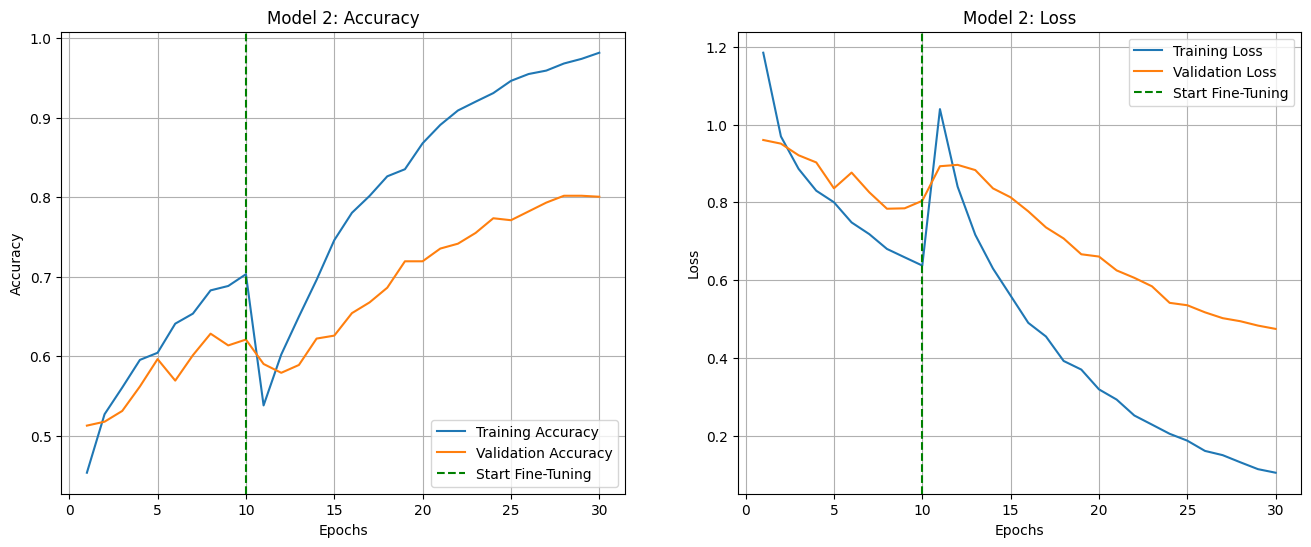

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step

Model 2: ResNet50V2 Classification Report
                    precision    recall  f1-score   support

      NoImpairment       0.89      0.82      0.85       512
    MildImpairment       0.78      0.80      0.79       358
ModerateImpairment       0.72      0.85      0.78       144

          accuracy                           0.82      1014
         macro avg       0.79      0.83      0.81      1014
      weighted avg       0.82      0.82      0.82      1014



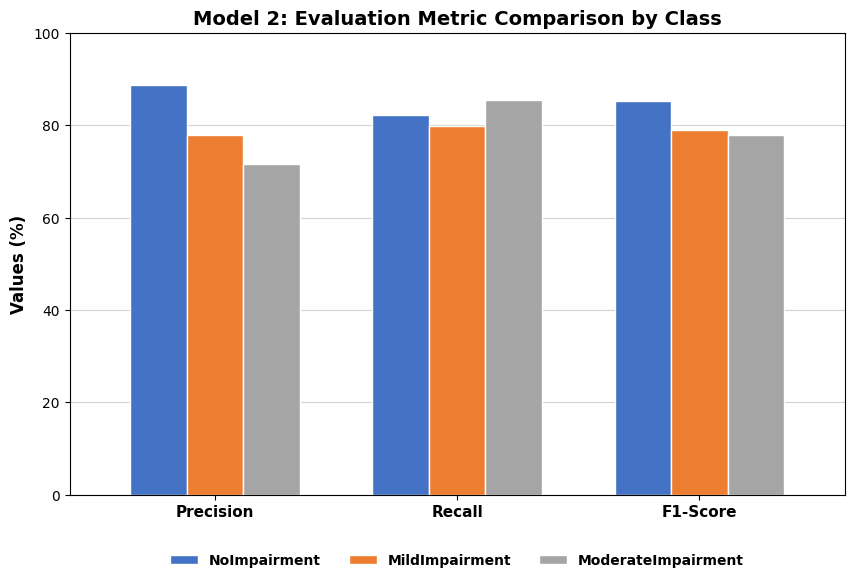

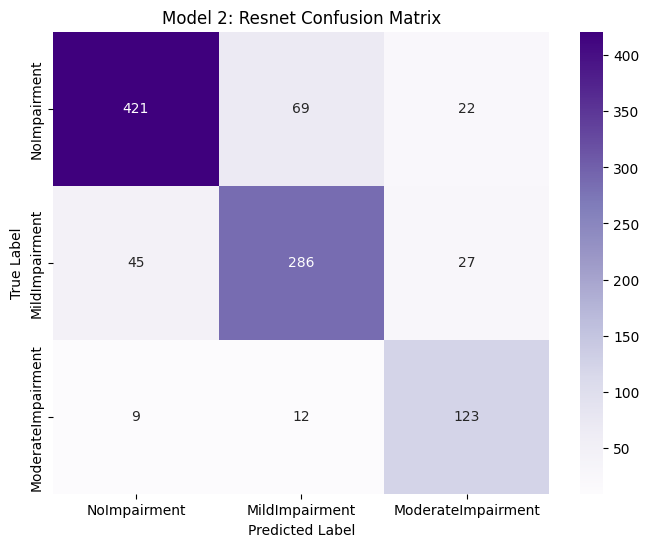

In [23]:
# Evaluating ResNet Results


# Combining History for Plotting (warm-up + fine-tuning)
acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_warmup.history['loss'] + history_finetune.history['loss']
val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(1, len(acc) + 1)
finetune_start = len(history_warmup.history['accuracy']) # Marker for plot


# Plotting
plt.figure(figsize=(16, 6))


# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=finetune_start, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('Model 2: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)


# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=finetune_start, color='green', linestyle='--', label='Start Fine-Tuning')
plt.title('Model 2: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


# Classification Report
predictions = resnet_model.predict(xtest)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(ytest, axis=1) # Decode One-Hot

class_names = ['NoImpairment', 'MildImpairment', 'ModerateImpairment']

print("\n" + "="*50)
print("Model 2: ResNet50V2 Classification Report")
print("="*50)
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Generate report as dictionary for the chart
report_dict = classification_report(y_true_classes, y_pred_classes, target_names=class_names, output_dict=True)

# Format the dataframe for the styled chart (Metrics on X-axis, Classes as bars)
df = pd.DataFrame(report_dict).T.drop(['accuracy', 'macro avg', 'weighted avg'])[['precision', 'recall', 'f1-score']]
plot_df = df.T * 100  # Multiply by 100 for percentage scale

# Plot the styled bar chart
colors = ['#4472C4', '#ED7D31', '#A5A5A5'] # Academic Blue, Orange, Grey
ax_bar = plot_df.plot(kind='bar', figsize=(10, 6), color=colors, width=0.7, edgecolor='white')

plt.title('Model 2: Evaluation Metric Comparison by Class', fontweight='bold', fontsize=14)
plt.ylabel('Values (%)', fontweight='bold', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Precision', 'Recall', 'F1-Score'], rotation=0, fontweight='bold', fontsize=11)
plt.ylim(0, 100)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, prop={'weight':'bold'})
ax_bar.set_axisbelow(True)
plt.grid(axis='y', color='lightgray', linestyle='-')
plt.show()


# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Model 2: Resnet Confusion Matrix')
plt.show()



# <font size="8">ROC Curve: Comparing Model Performance</font>


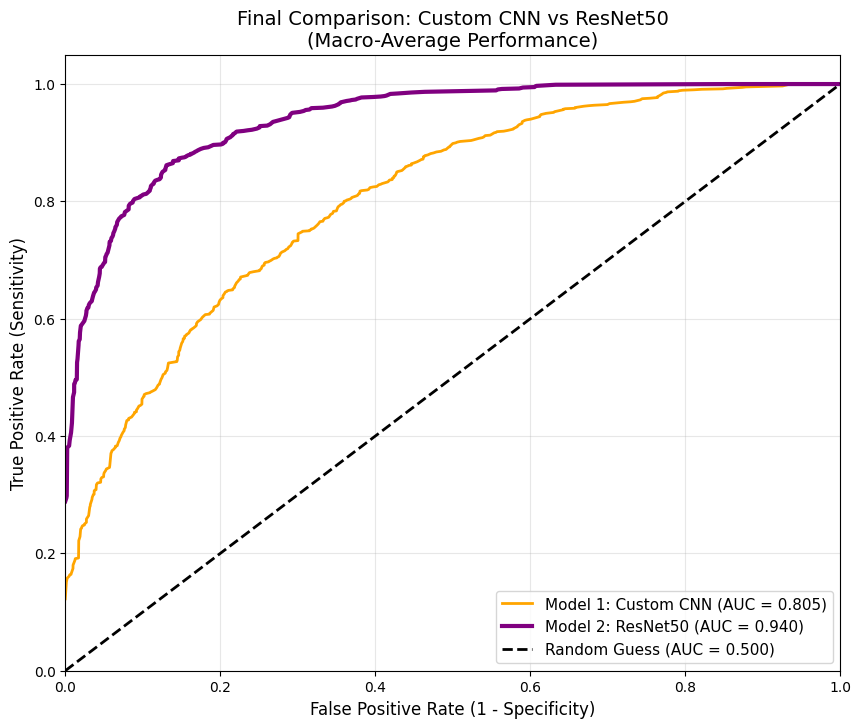

In [25]:
# ROC curve compares true positive rate (sensitivity) against false positive rate (1-specifity)
# Sensitivity: the models ability to correctly identify the disease when it is actually present
# 1-specificty: the probability of the model inccorectly diagnosing a healthy patient with the disease
# Macro-average approach calculates ROC for each class seperately, and then averages them together
# This ensures that the performance on the minority class is given equal weight to majority


# Calculating Macro-Average ROC curve
def get_macro_roc_curve(model, X, y_true):
    y_pred = model.predict(X, verbose=0)
    n_classes = y_true.shape[1]

    # Calculating FPR/TPR for each class separately
    all_fpr = np.unique(np.concatenate([roc_curve(y_true[:, i], y_pred[:, i])[0] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    # Linearly interpolate TPRs for each class to match the common FPR scale
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    # Average the results (Macro Averaging)
    mean_tpr /= n_classes

    # Calculating final AUC
    roc_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, roc_auc



# Visualising the Comparison
plt.figure(figsize=(10, 8))

# Plotting Model 1 (Custom CNN)
fpr1, tpr1, auc1 = get_macro_roc_curve(model, xval, yval)
plt.plot(fpr1, tpr1, label=f'Model 1: Custom CNN (AUC = {auc1:.3f})',
         color='orange', linewidth=2)

# Plotting Model 2 (ResNet50)
fpr2, tpr2, auc2 = get_macro_roc_curve(resnet_model, xval, yval)
plt.plot(fpr2, tpr2, label=f'Model 2: ResNet50 (AUC = {auc2:.3f})',
         color='purple', linewidth=3)

# Adding "Random Guess" Line
# This is a diagonal line representing a model with zero predictive skill (Random Chance)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Final Comparison: Custom CNN vs ResNet50\n(Macro-Average Performance)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()